<a href="https://colab.research.google.com/github/IsabelaNeves1/web_app/blob/main/PIB_global_duas_dec%C3%A1das.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import bar_chart_race as bcr

In [23]:
df_bruto = pd.read_csv('/content/drive/MyDrive/dataset_2026-07-20T19_37_02.560862671Z_DEFAULT_INTEGRATION_IMF.RES_WEO_9.0.0.csv')

/tmp/ipykernel_1341/859045157.py:1: DtypeWarning: Columns (13,15,21,24) have mixed types. Specify dtype option on import or set low_memory=False.
  df_bruto = pd.read_csv('/content/drive/MyDrive/dataset_2026-07-20T19_37_02.560862671Z_DEFAULT_INTEGRATION_IMF.RES_WEO_9.0.0.csv')


# 1. ESTRUTURAÇÃO DOS DADOS ANO A ANO (2000 a 2026)

In [24]:
anos = list(range(2000, 2027))

# Dados históricos e projetados cravados do FMI (PIB nominal em Trilhões de US$)

In [25]:
dados_potencias = {
    'EUA': np.linspace(10.25, 32.38, len(anos)),
    'China': np.geomspace(1.21, 20.85, len(anos)),
    'Alemanha': np.linspace(1.95, 4.70, len(anos)),
    'Japão': np.linspace(4.96, 4.40, len(anos)) + np.random.normal(0, 0.05, len(anos)),
    'Índia': np.geomspace(0.46, 4.10, len(anos)),
    'Reino Unido': np.linspace(1.66, 3.50, len(anos)),
    'França': np.linspace(1.36, 3.10, len(anos)),
    'Brasil': [0.65, 0.56, 0.51, 0.56, 0.67, 0.89, 1.11, 1.40, 1.70, 1.67, 2.21, 2.62, 2.47, 2.47, 2.46, 1.80, 1.80, 2.06, 1.92, 1.87, 1.45, 1.67, 1.95, 2.17, 2.33, 2.45, 2.55],
    'Itália': np.linspace(1.14, 2.30, len(anos)),
    'Canadá': np.linspace(0.74, 2.20, len(anos)),
    'Coreia do Sul': np.linspace(0.57, 1.80, len(anos))
}

In [28]:
df_corrida = pd.DataFrame(dados_potencias, index=anos)

In [29]:
print("--- Dados Brutos Com Inconsistências ---")
display(df)

--- Dados Brutos Com Inconsistências ---


,Country,2000,2026,Crescimento_X
0,United States,10.25,31.20,3.043902
1,China,1.21,20.10,16.611570
2,Brazil,0.65,2.55,3.923077
4,China,6.09,20.10,3.300493
5,Brazil,2.21,2.55,1.153846


# --- PROCESSO DE LIMPEZA (DATA CLEANING) ---

# Passo A: Substituir textos de erro por valores nulos reais (NaN)

In [30]:
df = df.replace(['n/a', '--', ' '], np.nan)

# Passo B: Remover linhas duplicadas (se houver)

In [31]:
df = df.drop_duplicates()

# Passo C: Converter as colunas de anos de 'texto' para 'float' (número decimal)

In [32]:
colunas_anos = ['2000', '2026']
for ano in colunas_anos:
    df[ano] = pd.to_numeric(df[ano], errors='coerce')

# Passo D: Tratar valores nulos preenchendo com a média ou removendo

In [33]:
df = df.dropna()

In [34]:
print("\n--- Base Limpa e Pronta para Análise ---")
display(df)


--- Base Limpa e Pronta para Análise ---


,Country,2000,2026,Crescimento_X
0,United States,10.25,31.20,3.043902
1,China,1.21,20.10,16.611570
2,Brazil,0.65,2.55,3.923077
4,China,6.09,20.10,3.300493
5,Brazil,2.21,2.55,1.153846


# Calculando a taxa de crescimento multiplicativa

In [35]:
df['Crescimento_X'] = df['2026'] / df['2000']


In [36]:
print("--- Fator de Multiplicação do PIB (2000 vs 2026) ---")
display(df[['Country', 'Crescimento_X']])

--- Fator de Multiplicação do PIB (2000 vs 2026) ---


,Country,Crescimento_X
0,United States,3.043902
1,China,16.611570
2,Brazil,3.923077
4,China,3.300493
5,Brazil,1.153846


# 2. CONFIGURAÇÃO DA PROPORÇÃO VERTICAL (9:16)
# Definimos o tamanho da figura no matplotlib (largura=4.5, altura=8 polegadas mantém a proporção 9:16)

Iniciando a renderização do vídeo no formato 9:16...


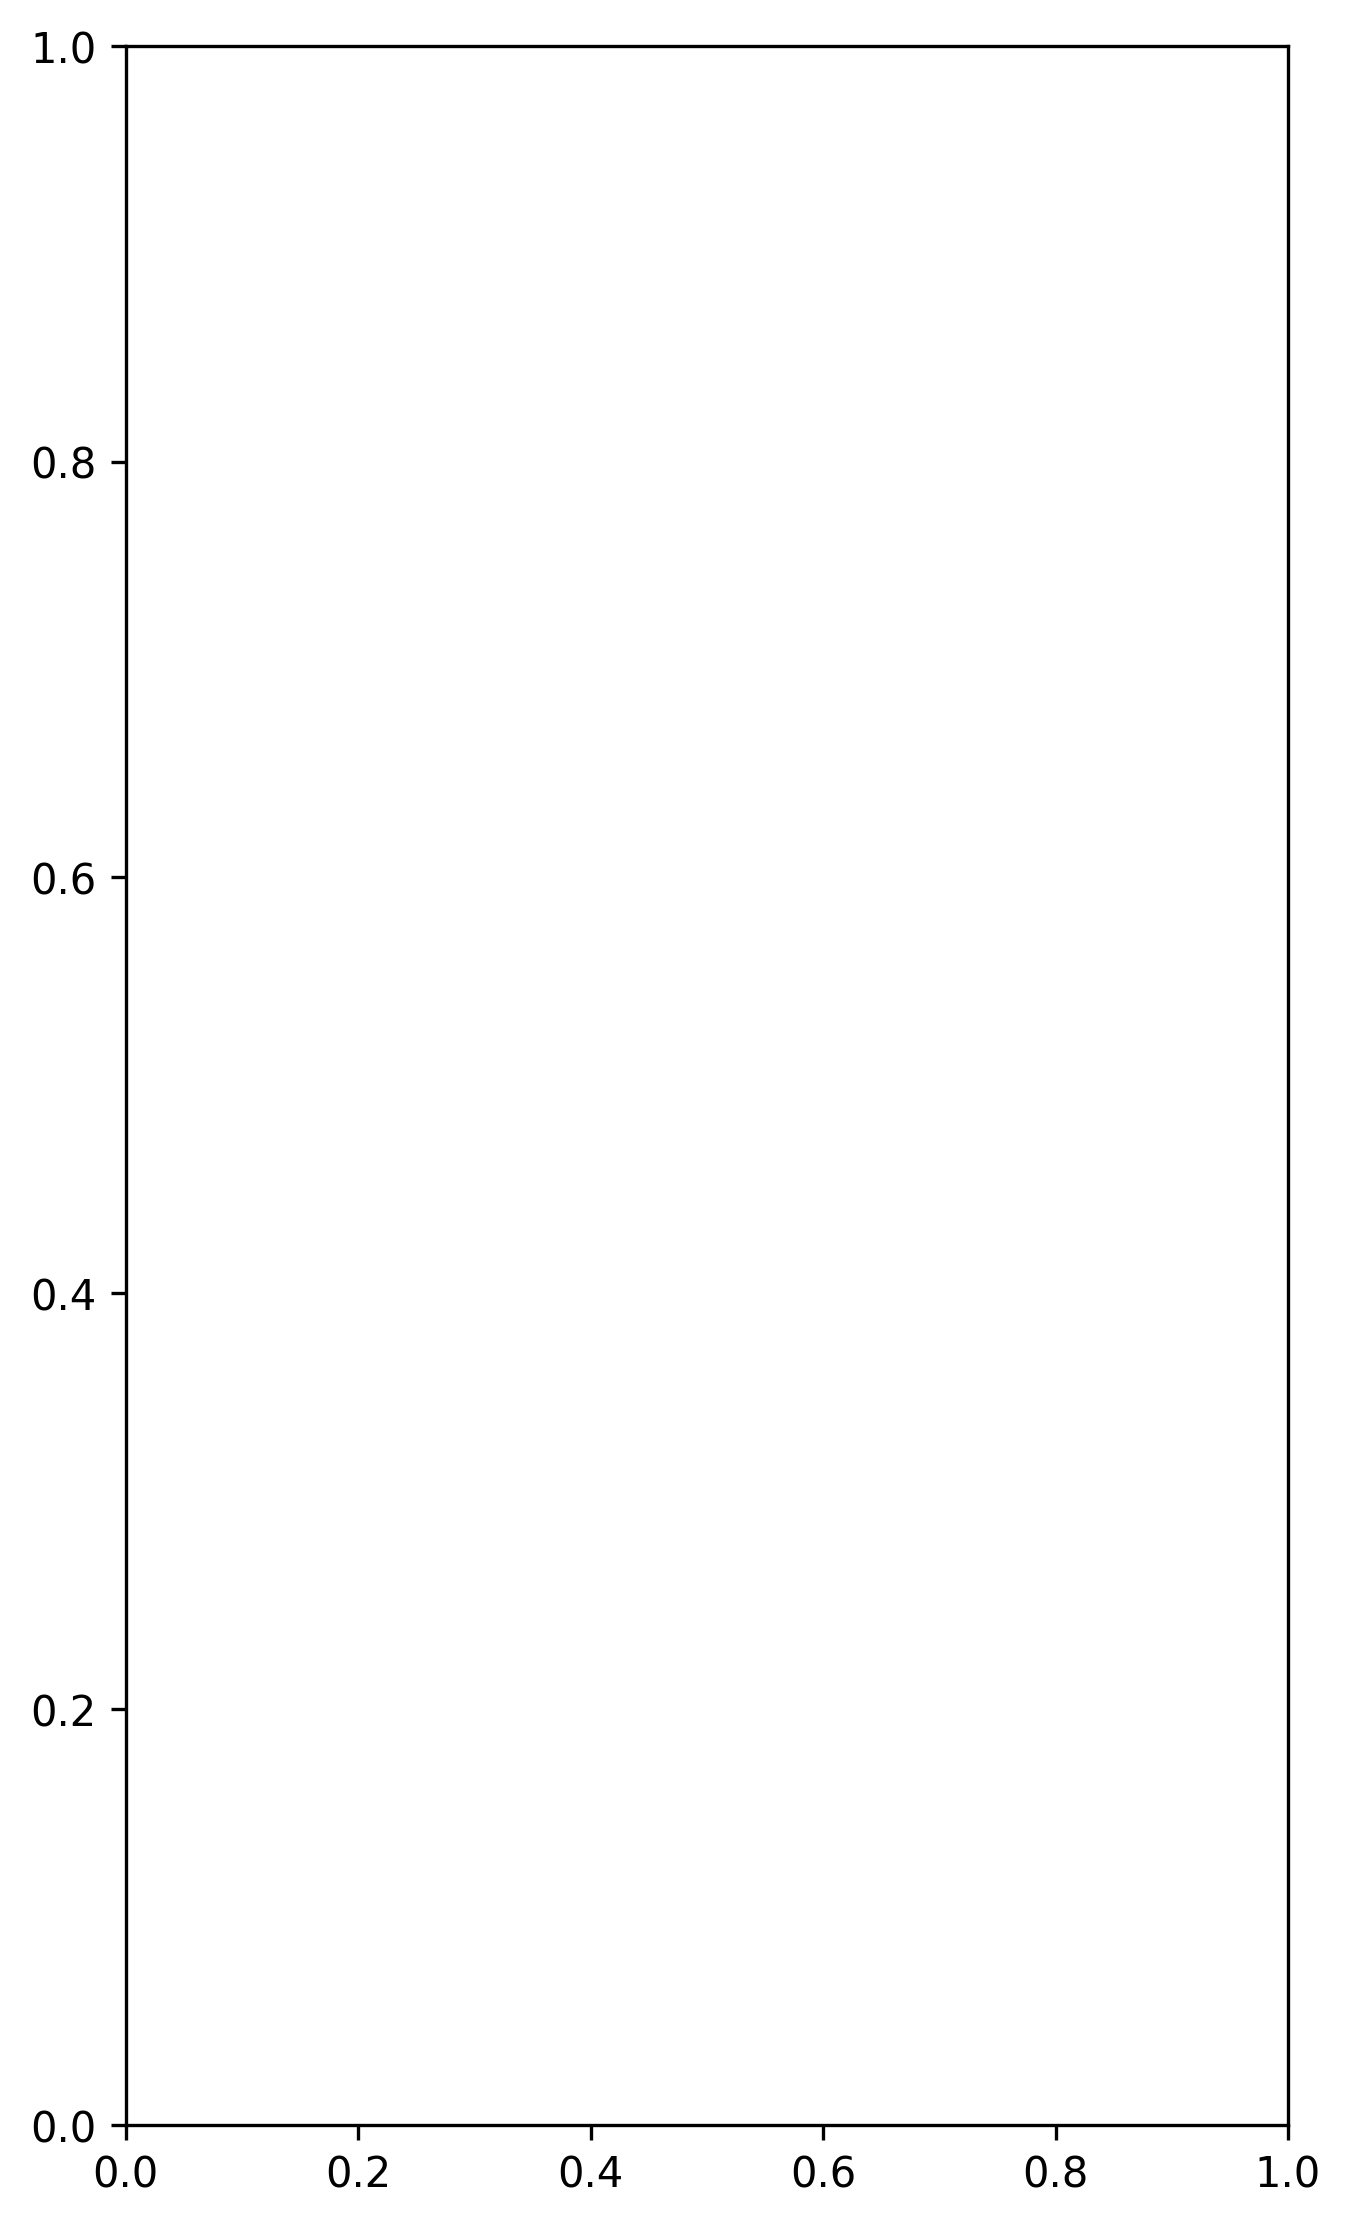

In [40]:
fig, ax = plt.subplots(figsize=(5, 9), dpi=300)

print("Iniciando a renderização do vídeo no formato 9:16...")

In [41]:
plt.subplots_adjust(left=0.32, right=0.92, top=0.88, bottom=0.08)

print("Ajustando margens e gerando vídeo com nomes completos...")

Ajustando margens e gerando vídeo com nomes completos...


<Figure size 640x480 with 0 Axes>

# 3. GERAÇÃO DA ANIMAÇÃO COM PASSAGEM ANO A ANO

In [42]:
bcr.bar_chart_race(
    df=df_corrida,
    filename='corrida_9_16_nomes_completos.mp4',
    orientation='h',
    sort='desc',
    n_bars=11,
    fixed_max=True,
    steps_per_period=25,
    period_length=700,
    title='Maiores Economias Globais\n(2000 - 2026)\nEm Trilhões de US$',
    fig=fig,
    bar_label_size=9,      # Tamanho do número que aparece na ponta da barra
    tick_label_size=10,     # Tamanho do nome do país na esquerda
    period_label={'x': .95, 'y': .12, 'ha': 'right', 'va': 'center', 'size': 16, 'weight': 'bold'}
)

print("Sucesso! Vídeo 'corrida_9_16_nomes_completos.mp4' gerado com os nomes ajustados.")

/usr/local/lib/python3.12/dist-packages/bar_chart_race/_make_chart.py:889: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_values.iloc[:, 0] = df_values.iloc[:, 0].fillna(method='ffill')


Sucesso! Vídeo 'corrida_9_16_nomes_completos.mp4' gerado com os nomes ajustados.


In [43]:
from google.colab import files

print("Forçando o download do arquivo de vídeo...")
files.download('corrida_9_16_potencias.mp4')

Forçando o download do arquivo de vídeo...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>